In [2]:
pip install wordcloud

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.


In [3]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from wordcloud import WordCloud

import warnings
warnings.filterwarnings("ignore")

plt.style.use("ggplot")

pd.set_option("display.max_columns", None)

In [4]:
df = pd.read_csv("../data/processed/basic_clean.csv")

df.head()

,idd,title,text,label,text_length
0,Fq+C96tcx+,‘A target on Roe v. Wade ’: Oklahoma bill maki...,UPDATE: Gov. Fallin vetoed the bill on Friday....,REAL,6677
1,bHUqK!pgmv,Study: women had to drive 4 times farther afte...,Ever since Texas laws closed about half of the...,REAL,4044
2,4Y4Ubf%aTi,"Trump, Clinton clash in dueling DC speeches","Donald Trump and Hillary Clinton, now at the s...",REAL,3274
3,_CoY89SJ@K,Grand jury in Texas indicts activists behind P...,A Houston grand jury investigating criminal al...,REAL,5316
4,+rJHoRQVLe,"As Reproductive Rights Hang In The Balance, De...",WASHINGTON -- Forty-three years after the Supr...,REAL,2660


In [5]:
print("Rows :", df.shape[0])
print("Columns :", df.shape[1])

Rows : 4593
Columns : 5


In [6]:
df["label"].value_counts()

label
FAKE    2297
REAL    2296
Name: count, dtype: int64

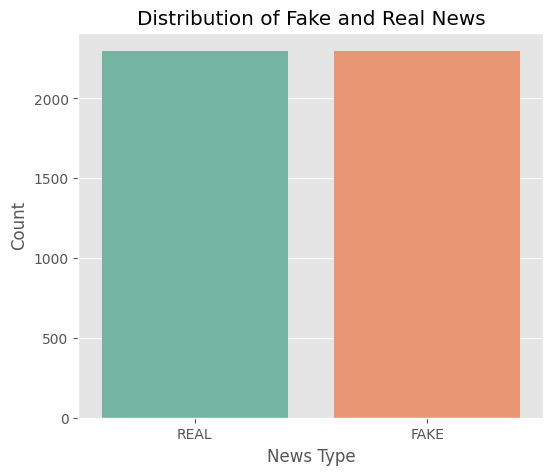

In [7]:
plt.figure(figsize=(6,5))

sns.countplot(data=df, x="label", palette="Set2")

plt.title("Distribution of Fake and Real News")
plt.xlabel("News Type")
plt.ylabel("Count")

plt.show()

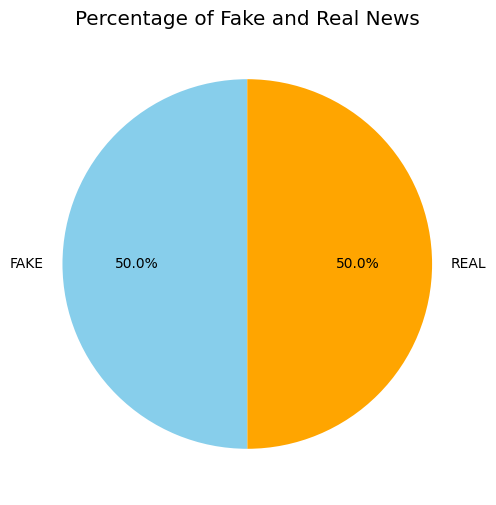

In [8]:
df["label"].value_counts().plot(
    kind="pie",
    autopct="%1.1f%%",
    figsize=(6,6),
    startangle=90,
    colors=["skyblue","orange"]
)

plt.ylabel("")
plt.title("Percentage of Fake and Real News")

plt.show()

In [9]:
df["text_length"] = df["text"].apply(len)

df.head()

,idd,title,text,label,text_length
0,Fq+C96tcx+,‘A target on Roe v. Wade ’: Oklahoma bill maki...,UPDATE: Gov. Fallin vetoed the bill on Friday....,REAL,6677
1,bHUqK!pgmv,Study: women had to drive 4 times farther afte...,Ever since Texas laws closed about half of the...,REAL,4044
2,4Y4Ubf%aTi,"Trump, Clinton clash in dueling DC speeches","Donald Trump and Hillary Clinton, now at the s...",REAL,3274
3,_CoY89SJ@K,Grand jury in Texas indicts activists behind P...,A Houston grand jury investigating criminal al...,REAL,5316
4,+rJHoRQVLe,"As Reproductive Rights Hang In The Balance, De...",WASHINGTON -- Forty-three years after the Supr...,REAL,2660


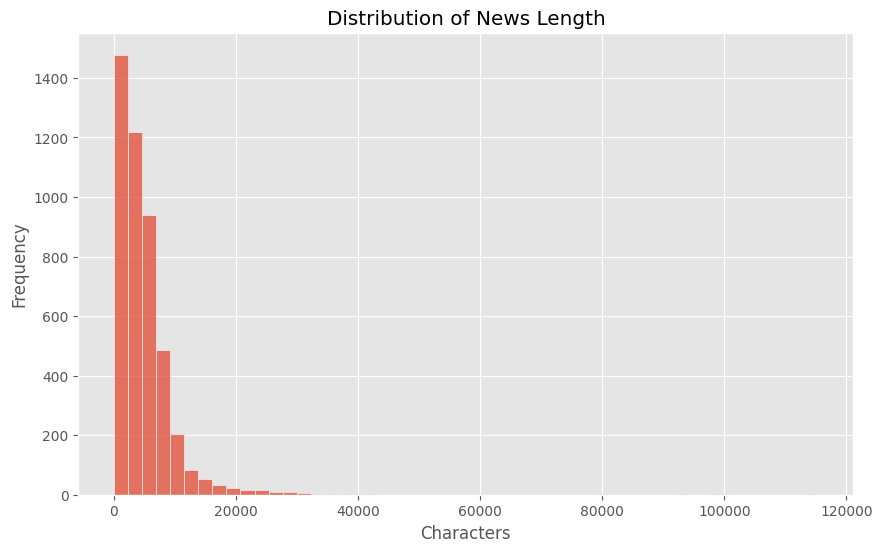

In [10]:
plt.figure(figsize=(10,6))

sns.histplot(df["text_length"], bins=50)

plt.title("Distribution of News Length")

plt.xlabel("Characters")

plt.ylabel("Frequency")

plt.show()

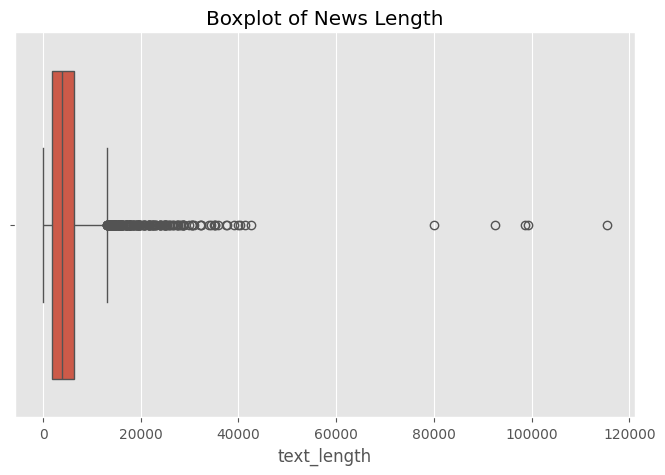

In [11]:
plt.figure(figsize=(8,5))

sns.boxplot(x=df["text_length"])

plt.title("Boxplot of News Length")

plt.show()

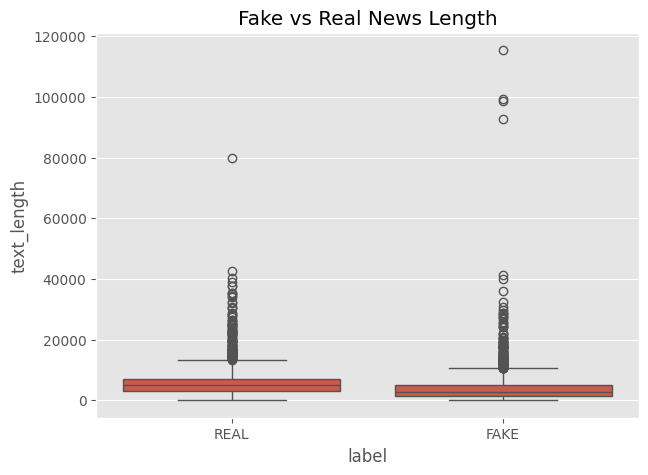

In [12]:
plt.figure(figsize=(7,5))

sns.boxplot(data=df, x="label", y="text_length")

plt.title("Fake vs Real News Length")

plt.show()

In [13]:
df.groupby("label")["text_length"].mean()

label
FAKE    4032.503700
REAL    5693.293554
Name: text_length, dtype: float64

In [14]:
df.sort_values(by="text_length", ascending=False).head()

,idd,title,text,label,text_length
3293,eydp4vvCP^,Re: Why Are So Many People Choosing To Leave T...,Why Are So Many People Choosing To Leave The U...,FAKE,115372
2638,*mK5K7t2Tz,Re: It Is Now Mathematically Impossible To Pay...,It Is Now Mathematically Impossible To Pay Off...,FAKE,99355
2728,SATOjfNTW6,Re: 55 Reasons Why California Is The Worst Sta...,55 Reasons Why California Is The Worst State I...,FAKE,98698
3202,)5SsnT6&eE,Benny Morris’s Untenable Denial of the Ethnic ...,References The Debate \nIt started when Daniel...,FAKE,92561
918,kvd$&UD4Dj,"One year, two races: Inside the Republican Par...",It is an oppressively humid day in South Flori...,REAL,79953


In [15]:
df.sort_values(by="text_length").head()

,idd,title,text,label,text_length
3177,tJ)NySnd79,"Hope for the best, prepare for the worst…",,FAKE,1
3970,Y*yebIEU5w,Huma’s Weiner Dogs Hillary,,FAKE,1
3601,NLFE4x3lt!,"David Duke, Donald Trump, and the Alt Right",,FAKE,1
4184,t1mo3PZ%SP,Hillary’s Watergate?,,FAKE,1
3091,0Fym!%gU17,Thomas Frank Explores Whether Hillary Clinton ...,,FAKE,1


In [16]:
df["word_count"] = df["text"].apply(lambda x: len(str(x).split()))

In [17]:
df["word_count"].describe()

count     4593.000000
mean       804.151535
std        930.255901
min          0.000000
25%        290.000000
50%        634.000000
75%       1041.000000
max      20891.000000
Name: word_count, dtype: float64

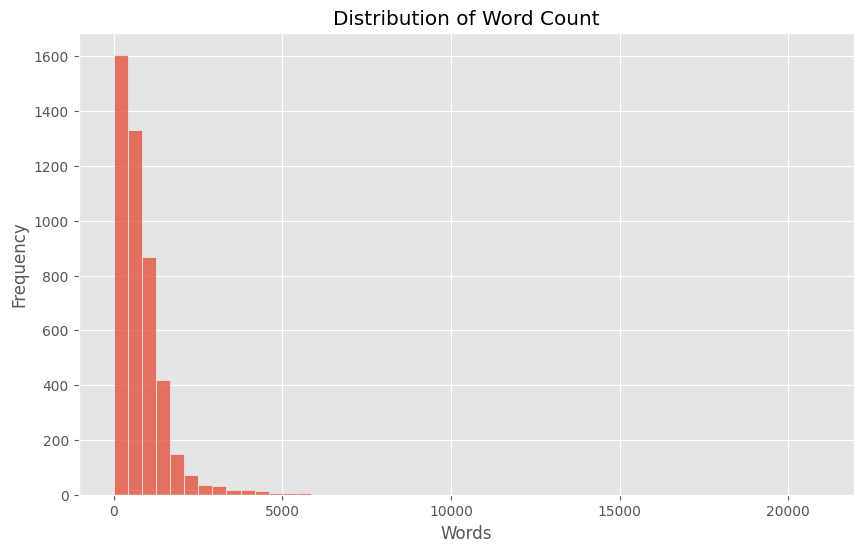

In [18]:
plt.figure(figsize=(10,6))

sns.histplot(df["word_count"], bins=50)

plt.title("Distribution of Word Count")

plt.xlabel("Words")

plt.ylabel("Frequency")

plt.show()

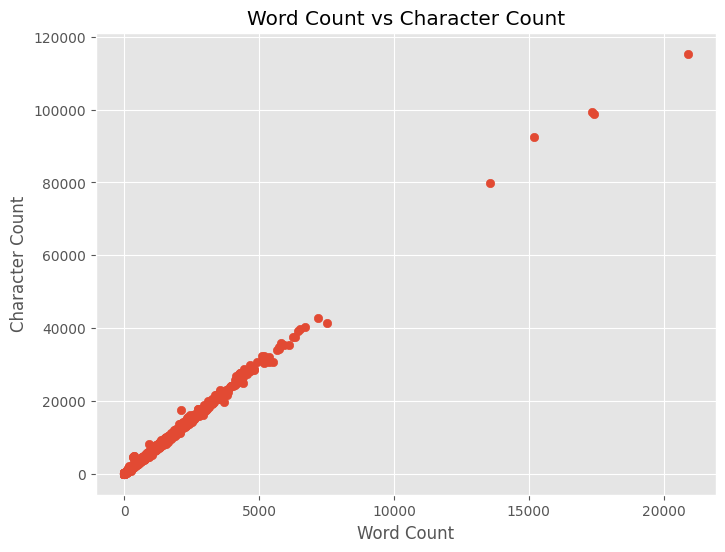

In [19]:
plt.figure(figsize=(8,6))

plt.scatter(df["word_count"], df["text_length"])

plt.xlabel("Word Count")

plt.ylabel("Character Count")

plt.title("Word Count vs Character Count")

plt.show()

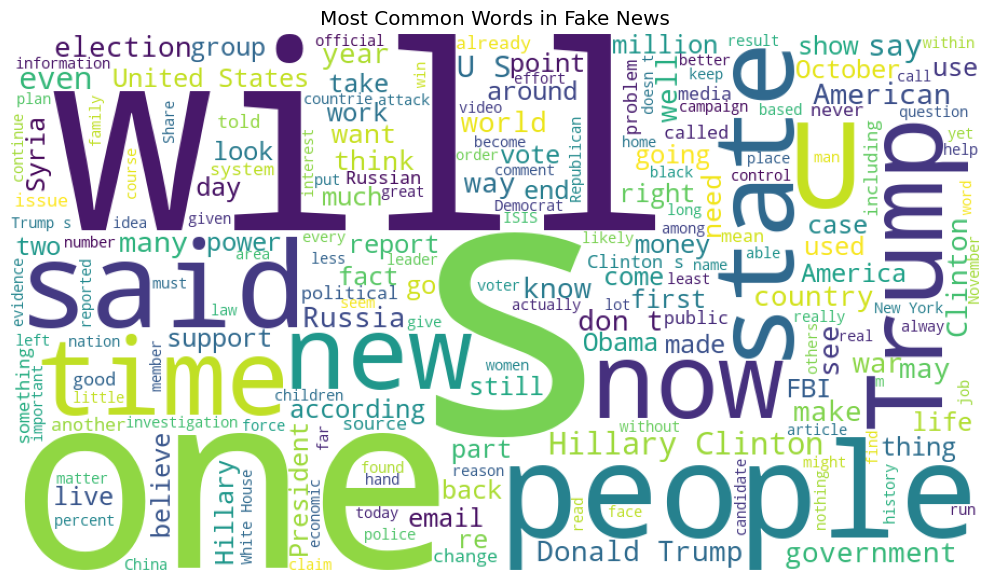

In [20]:
fake_news = " ".join(df[df["label"]=="FAKE"]["text"])

wordcloud = WordCloud(
    width=900,
    height=500,
    background_color="white"
).generate(fake_news)

plt.figure(figsize=(15,7))

plt.imshow(wordcloud)

plt.axis("off")

plt.title("Most Common Words in Fake News")

plt.show()

In [21]:
from collections import Counter

words = " ".join(df["text"]).split()

counter = Counter(words)

top_words = counter.most_common(20)

top_words

[('the', 187660),
 ('to', 101720),
 ('of', 93455),
 ('and', 83167),
 ('a', 78144),
 ('in', 68070),
 ('that', 47116),
 ('is', 38556),
 ('for', 32778),
 ('on', 28519),
 ('with', 22347),
 ('as', 21999),
 ('was', 20302),
 ('he', 19342),
 ('The', 19306),
 ('his', 18635),
 ('are', 17766),
 ('have', 17687),
 ('be', 17687),
 ('Trump', 17674)]

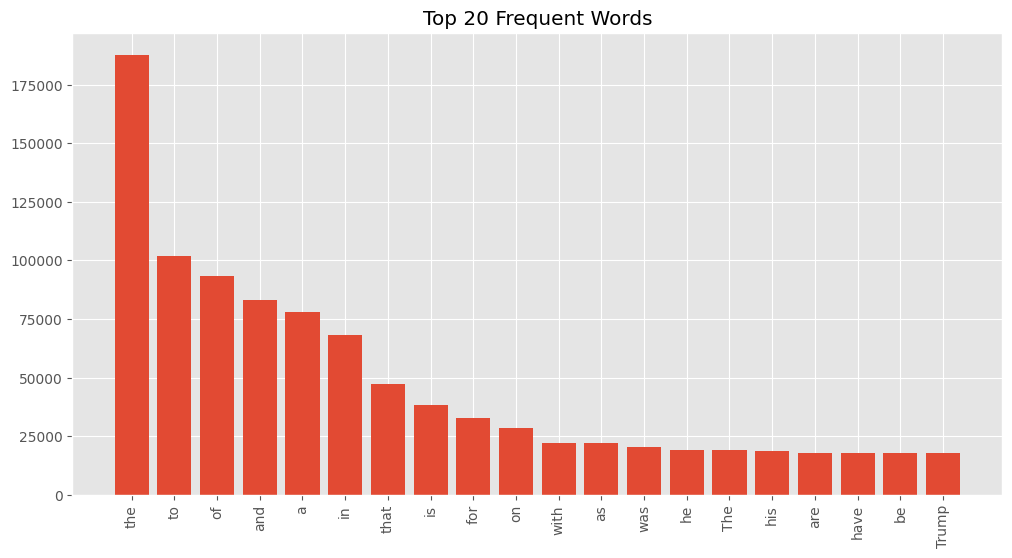

In [22]:
words = [i[0] for i in top_words]

counts = [i[1] for i in top_words]

plt.figure(figsize=(12,6))

plt.bar(words, counts)

plt.xticks(rotation=90)

plt.title("Top 20 Frequent Words")

plt.show()

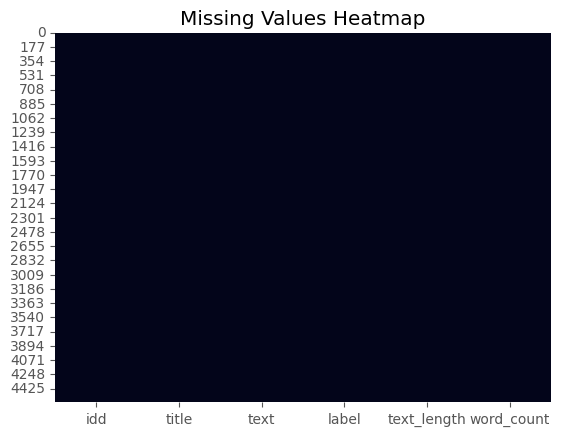

In [23]:
sns.heatmap(df.isnull(), cbar=False)

plt.title("Missing Values Heatmap")

plt.show()

In [24]:
numeric_columns = df.select_dtypes(include=np.number)

numeric_columns.corr()

,text_length,word_count
text_length,1.000000,0.998384
word_count,0.998384,1.000000


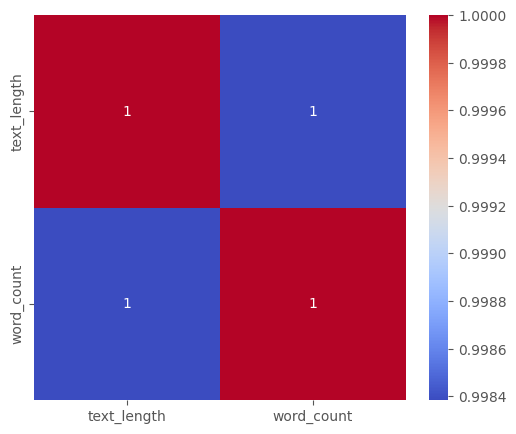

In [25]:
plt.figure(figsize=(6,5))

sns.heatmap(
    numeric_columns.corr(),
    annot=True,
    cmap="coolwarm"
)

plt.show()

In [26]:
df.to_csv("../data/processed/eda_completed.csv", index=False)

In [27]:
print("="*60)
print("EDA Completed Successfully")
print("="*60)

print("Total Articles :", len(df))
print()

print(df["label"].value_counts())

print()

print("Average News Length :", round(df["text_length"].mean(),2))

print("Average Word Count :", round(df["word_count"].mean(),2))

EDA Completed Successfully
Total Articles : 4593

label
FAKE    2297
REAL    2296
Name: count, dtype: int64

Average News Length : 4862.72
Average Word Count : 804.15


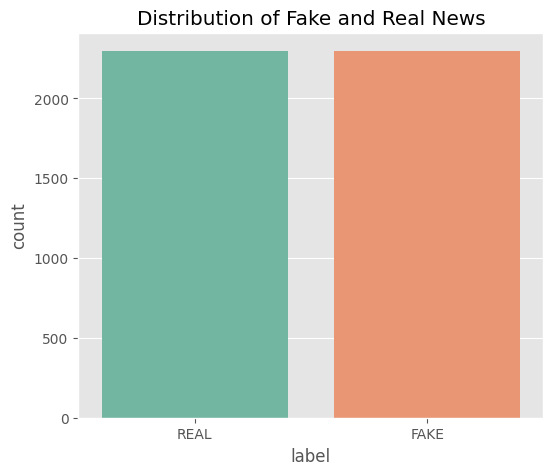

In [28]:
plt.figure(figsize=(6,5))
sns.countplot(data=df, x="label", palette="Set2")
plt.title("Distribution of Fake and Real News")

plt.savefig("../images/class_distribution.png", dpi=300, bbox_inches="tight")

plt.show()